In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

housing = pd.read_csv("housing.csv")

# buat kategori berdasarkan median_income agar tes set sesuai dengan proporsi ditribusi median_income
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5],
)

# buat data train dan test dengan stratified sampling berdasarkan income_cat
train_set, test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42
)

# cek hasil proporsi income_cat di test set dan train set
test_set["income_cat"].value_counts() / len(test_set)
train_set["income_cat"].value_counts() / len(train_set)


# hapus kolom income_cat karena sudah tidak diperlukan lagi
for set_ in (train_set, test_set):
    set_.drop("income_cat", axis=1, inplace=True)



In [11]:
housing= train_set.copy()

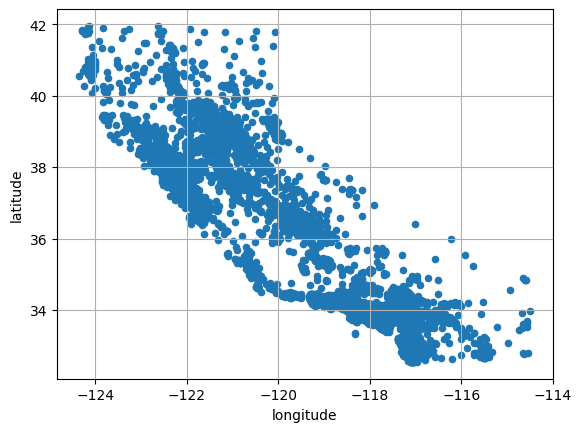

In [15]:
#viusalisasi data geografis
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
plt.show()

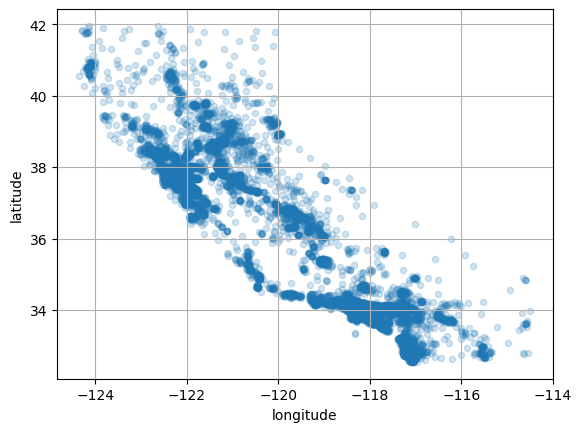

In [16]:
#viusalisasi data geografis revision
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

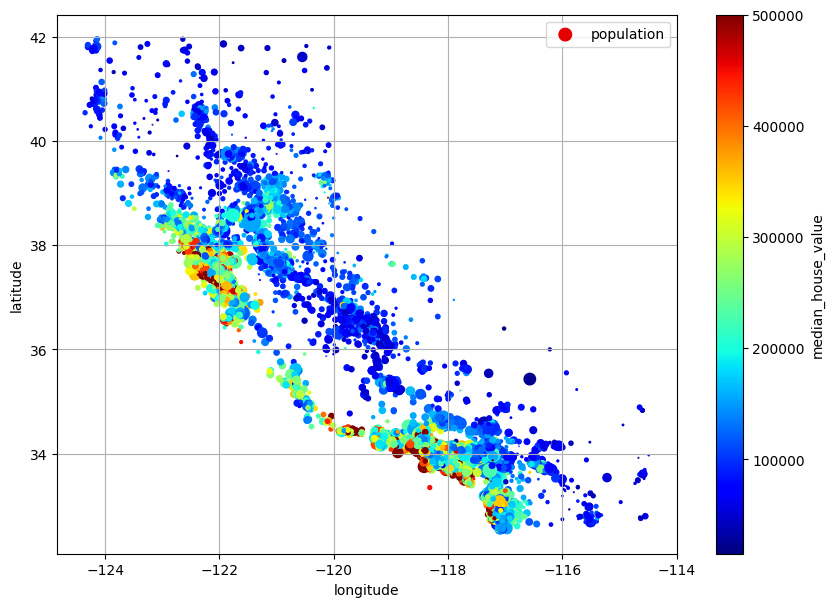

In [38]:
#viusalisasi data geografis lebih kompleks dengan ukuran dan warna berdasarkan populasi dan harga
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
 s=housing["population"] / 100, label="population",
 c="median_house_value", cmap="jet", colorbar=True,
 legend=True, sharex=False, figsize=(10, 7))
plt.show()